In [87]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [88]:
df = pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [89]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [90]:
df.shape

(10000, 14)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [92]:
df.duplicated().sum()

np.int64(0)

In [93]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [94]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [95]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [96]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [97]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [98]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int)

In [99]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [100]:
X = df.drop(columns=['Exited'])
y = df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [101]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [102]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [103]:
X.shape

(10000, 11)

In [104]:
y.shape

(10000,)

In [105]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [106]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [107]:
X_test_scaled

array([[-1.03768121,  0.77498705, -1.0482813 , ..., -0.58312392,
        -0.57273139,  0.91509065],
       [ 0.30708683, -0.46686456, -0.70174202, ..., -0.58312392,
        -0.57273139,  0.91509065],
       [-1.23422423,  0.29735181, -1.0482813 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       ...,
       [-0.86182692, -0.46686456,  1.72403288, ..., -0.58312392,
         1.74601919,  0.91509065],
       [-0.30323097, -0.84897275, -1.0482813 , ...,  1.71490137,
        -0.57273139, -1.09278791],
       [ 0.04847759,  1.25262228,  1.3774936 , ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(2000, 11))

In [108]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [123]:
model = Sequential()

model.add(Dense(11,activation='relu',input_dim = 11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [124]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [125]:
history = model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7514 - loss: 0.5520 - val_accuracy: 0.7975 - val_loss: 0.4784
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8077 - loss: 0.4545 - val_accuracy: 0.8125 - val_loss: 0.4438
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8197 - loss: 0.4294 - val_accuracy: 0.8144 - val_loss: 0.4320
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8234 - loss: 0.4180 - val_accuracy: 0.8194 - val_loss: 0.4251
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8263 - loss: 0.4101 - val_accuracy: 0.8219 - val_loss: 0.4157
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8319 - loss: 0.4012 - val_accuracy: 0.8275 - val_loss: 0.4062
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8377 - loss: 0.3916 - val_accuracy: 0.8363 - val_loss: 0.3940
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8436 - loss: 0.3813 - val_accu

In [116]:
model.layers[0].get_weights()

[array([[-0.05457087, -0.1253084 ,  0.06660984, -0.05113729, -0.02835599,
          0.21865581, -0.36995378, -0.01537022, -0.27046645, -0.1331262 ,
          0.07461315],
        [-0.29746234,  1.3443865 , -0.08224387,  0.25619912, -0.45867208,
          0.01282311, -0.48650068,  1.0679308 , -0.25087452,  0.65314984,
         -0.5122081 ],
        [ 0.02916671, -0.12849969, -0.09528977, -0.7866411 , -0.42416978,
          0.00253122, -0.4591313 ,  0.33029872,  0.02875177,  0.24957809,
         -0.26163414],
        [-0.3948865 , -0.12220614, -0.4555857 , -0.21942882, -0.35823092,
         -0.38928095,  0.8076555 ,  0.37150463, -0.40360698, -0.363447  ,
         -0.5797513 ],
        [ 0.2688664 , -0.54227567, -1.1143272 ,  0.21045138,  1.0930256 ,
          0.31410915, -0.15151232,  0.6376046 , -0.34682643, -0.23848931,
         -0.08313879],
        [-0.2617871 , -0.09773344,  0.10142642,  0.41487873,  0.11175586,
          0.0944111 , -0.30056292, -0.22893162, -0.23647286,  0.0811939

In [117]:
model.layers[1].get_weights()

[array([[ 0.09930442, -1.1789355 , -0.06798631, -0.33528048,  0.27420792,
         -0.1116007 ,  0.3742233 , -0.3077606 , -0.04517097, -0.34021088,
          0.06080691],
        [ 0.01174006, -0.12945828,  0.5673621 , -0.40980664,  0.31065413,
          0.16183075,  0.02079007,  0.28767493, -0.5078214 , -0.10733995,
         -0.7658247 ],
        [-0.63221633, -0.2472629 ,  0.9101929 ,  0.1524388 ,  0.40793294,
         -1.6361065 , -0.3563795 , -0.60238534, -1.067276  ,  0.19521964,
         -0.6369147 ],
        [ 0.43683937,  0.59724724, -0.21071433,  0.07706645,  0.17908007,
         -1.0209194 ,  0.34500796,  0.40080884,  0.42016628,  0.66738176,
         -0.34763926],
        [ 0.91755146,  1.0297352 , -0.02670485,  0.2377868 ,  0.43063584,
          0.43195373, -1.0384834 ,  0.10732942,  0.33764628,  0.920956  ,
         -0.10877232],
        [ 0.05669152,  0.00209535, -0.04939811, -1.0173134 , -0.5903634 ,
          0.23803324,  0.31569287, -0.25956875,  0.77911586, -0.2063564

In [119]:
model.layers[2].get_weights()

[array([[ 1.079293  ],
        [ 1.1388292 ],
        [ 1.0099012 ],
        [-0.90205544],
        [-1.1897712 ],
        [ 1.6074483 ],
        [-0.31621227],
        [-0.9813837 ],
        [-1.2971088 ],
        [ 0.79866254],
        [-0.8395656 ]], dtype=float32),
 array([-0.09889165], dtype=float32)]

In [120]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [121]:
y_pred = np.where(y_log>0.5,1,0)

In [122]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8595

In [126]:
import matplotlib.pyplot as plt


In [128]:
history.history

{'accuracy': [0.7514062523841858,
  0.8076562285423279,
  0.8196874856948853,
  0.823437511920929,
  0.8262500166893005,
  0.8318750262260437,
  0.8376562595367432,
  0.8435937762260437,
  0.8492187261581421,
  0.852343738079071,
  0.8565624952316284,
  0.8584374785423279,
  0.858593761920929,
  0.8620312213897705,
  0.8600000143051147,
  0.8604687452316284,
  0.8609374761581421,
  0.8612499833106995,
  0.8621875047683716,
  0.862500011920929,
  0.8620312213897705,
  0.8606250286102295,
  0.86328125,
  0.8628125190734863,
  0.8623437285423279,
  0.8635937571525574,
  0.8631250262260437,
  0.864062488079071,
  0.8642187714576721,
  0.862500011920929,
  0.8631250262260437,
  0.8648437261581421,
  0.8645312786102295,
  0.8645312786102295,
  0.8631250262260437,
  0.8637499809265137,
  0.8628125190734863,
  0.864062488079071,
  0.8629687428474426,
  0.864062488079071,
  0.8645312786102295,
  0.8642187714576721,
  0.8639062643051147,
  0.8635937571525574,
  0.8653125166893005,
  0.8642187714

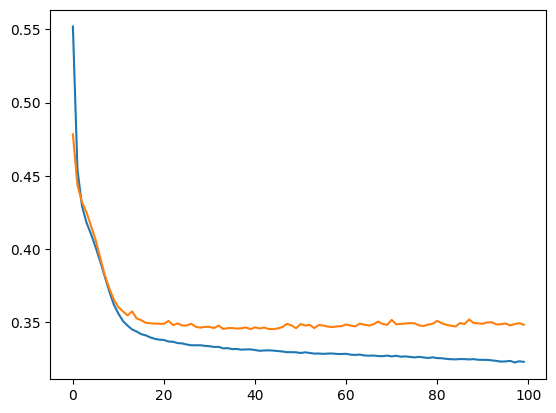

In [130]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

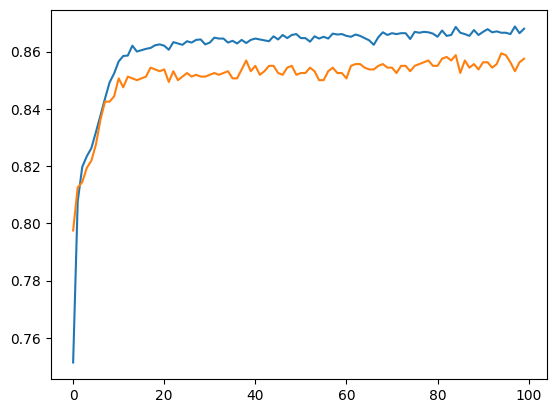

In [131]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])